# Q-Learning
In this notebook, you are going to implement a method of model-free reinforcement learning, called Q-Learning. This method follows an *off-policy* strategy. 

The total points of **Q-Learning** implementation is **40 POINTS**.

In [1]:
#run last to avoid graphics bug
#test_agent(env, target_policy, 1)

## Import the necessary software libraries:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gridworld import Environment
from utils import plot_policy, plot_action_values, test_agent

pygame 2.5.2 (SDL 2.28.3, Python 3.11.4)
Hello from the pygame community. https://www.pygame.org/contribute.html


## Create the environment, value table and policy

#### Create the environment

In [3]:
env = Environment()
state = env.reset()

#### Create the $Q(s, a)$ table

In [4]:
action_values = np.zeros((env.GH, env.GW, env.ACTIONS))

#### Create the target policy $\pi(s)$

In [5]:
def target_policy(state):
    av = action_values[state]
    return np.random.choice(np.flatnonzero(av == av.max()))

#### Create the exploratory policy using $\epsilon$-greedy strategy

In [14]:
#TODO: You need to implement the epsilon-greedy strategy as a exploratory policy. (10 points)
import random
def exploratory_policy(state):
    # Explore : With probability epsilon, we choose a random action with uniform probability, i.e explore
    # choose a value for epsilon
    epsilon = 0.3
    # p : probability 
    p = random.random()
    print('Probability', p)
    
    if p <= epsilon:
        # Explore: Choose a random action with uniform probability
        print('Exploration')
        return np.random.choice(len(action_values[state]))
    else:
        # Exploit: Choose the action with the maximum Q value
#         max_q_value = np.argmax(action_values[state])
#         best_action = np.random.choice(np.flatnonzero(max_q_value == max_q_value.max()))
        print('Exploitation')
        return target_policy(state)
    

state = (0,0)
print(exploratory_policy(state))

#### Plot the value table $Q(s,a)$

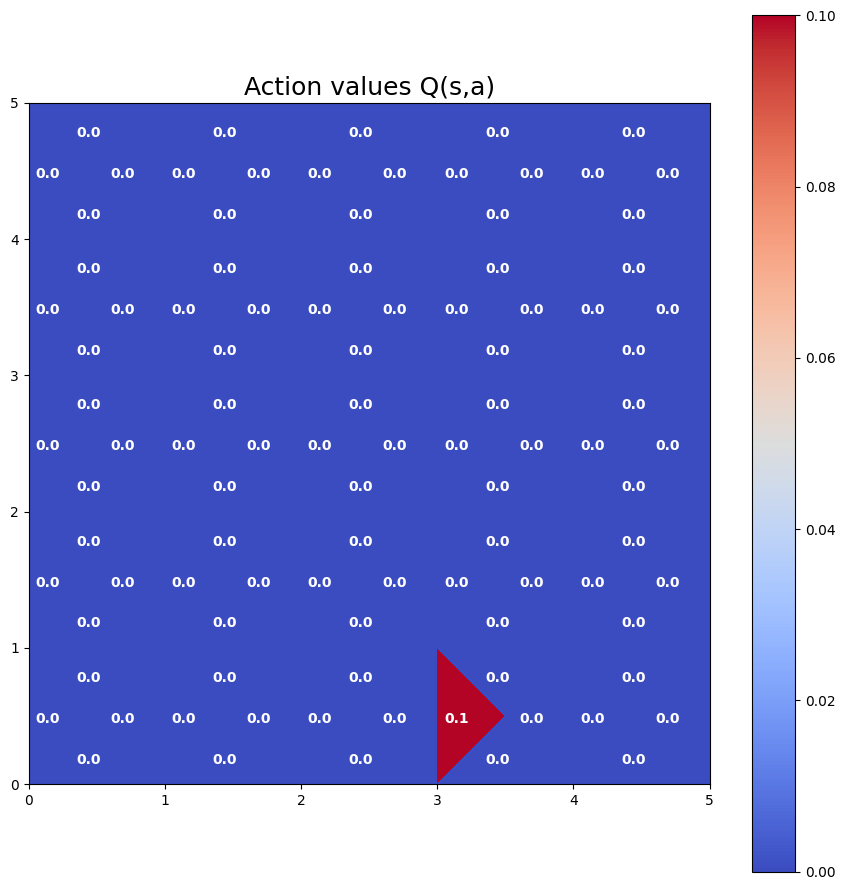

In [15]:
plot_action_values(action_values)

#### Plot the policy

<Figure size 600x600 with 0 Axes>

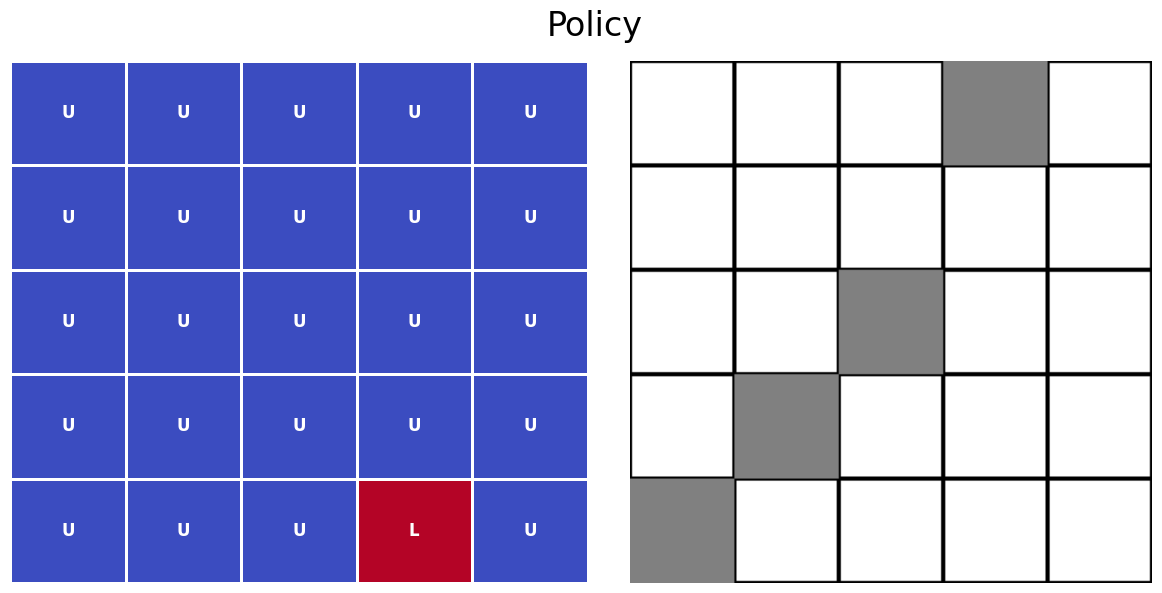

In [16]:
frame = env.render()
plt.figure(figsize=(6,6))
plot_policy(action_values, frame)

## Implement the algorithm

## Implement the Q-learning algorithm
<!-- <div style="text-align:center"> -->
<a target="_parent">
    <img src="q-learning.png" width="60%"/>
</a> 

Adapted from Barto & Sutton: "Reinforcement Learning: An Introduction".
<!-- </div> -->

In [17]:
def q_learning(action_values, exploratory_policy, target_policy, episodes, alpha=0.1, gamma=0.99):
    
    #TODO: You need to implement the Q-learning algorithm here.(30 points)
    
    #Commented Out:start_state=env.reset()
    #Commented Out:next_state=start_state
    
    for epi in range(episodes):
        #if env.noCollision(col,row):
        # Take an exploratory step
        
        #Added reset statements
        next_state = env.reset()
        test_terminal = False
        
        #Added while loop
        while not test_terminal:
        
            next_action = exploratory_policy(next_state)
        
            print(next_state)
                    
            #get outputs from step
            test_state, test_reward, test_terminal, test_info = env.step(next_action)
                    
            if test_terminal:
                Qterm=0
                Qtermp=0
            else:
                Qterm=action_values[(next_state[0],next_state[1],next_action)]
                #Qtermp_max=target_policy((next_state[0],next_state[1]))
                Qtermp=np.max(action_values[test_state[0],test_state[1],:])
                #Qtermp=action_values[test_state[0],test_state[1],Qtermp_max]
                #print("The output of target_policy is: ",Qtermp)
                #print("the output of target_policy(state) is: ", Qtermp_max)
                #print("the output of np.argmax(target_policy(state)) is: ", Qtermp_max)
            
                        
            #Update the action value
            action_values[next_state[0],next_state[1],next_action]=Qterm+alpha*(test_reward+gamma*Qtermp-Qterm)
        
            #update next_state
            next_state=test_state
        
            #print("Iteration: ",epi," changed state: (",next_state[0],",",next_state[1],"to: ",(action_values[next_state[0],next_state[1],next_action]))
            
    #TODO: Add comments to explain your code
    return 

for epi in range(1000):
    start_state=env.reset()
    next_action = exploratory_policy(state)
    test_reward,,,=step(next_action)

print(state)
print(next_state)

In [22]:
#TODO: Call the Q-learning algorithm after 1000 episodes
q_learning(action_values, exploratory_policy, target_policy, 1000)

Probability 0.20276133179610567
Exploration
(0, 0)
Probability 0.5207017761638413
Exploitation
(0, 0)
Probability 0.7973612434537345
Exploitation
(0, 0)
Probability 0.49794586631187954
Exploitation
(0, 0)
Probability 0.008255163451948655
Exploration
(0, 0)
Probability 0.8179548720523314
Exploitation
(0, 0)
Probability 0.3979289195922574
Exploitation
(0, 0)
Probability 0.008727398916384743
Exploration
(0, 0)
Probability 0.16359564316697794
Exploration
(0, 0)
Probability 0.04095389282249606
Exploration
(0, 0)
Probability 0.10167420051053166
Exploration
(0, 0)
Probability 0.45463009588772185
Exploitation
(1, 0)
Probability 0.5967461748876707
Exploitation
(1, 1)
Probability 0.8789008184053339
Exploitation
(1, 2)
Probability 0.8513607570075635
Exploitation
(1, 1)
Probability 0.43366114873923245
Exploitation
(1, 0)
Probability 0.3982663104822022
Exploitation
(2, 0)
Probability 0.5146934550942569
Exploitation
(2, 0)
Probability 0.895728175880893
Exploitation
(1, 0)
Probability 0.1150994502762

## Show results

#### Show resulting value table $Q(s,a)$

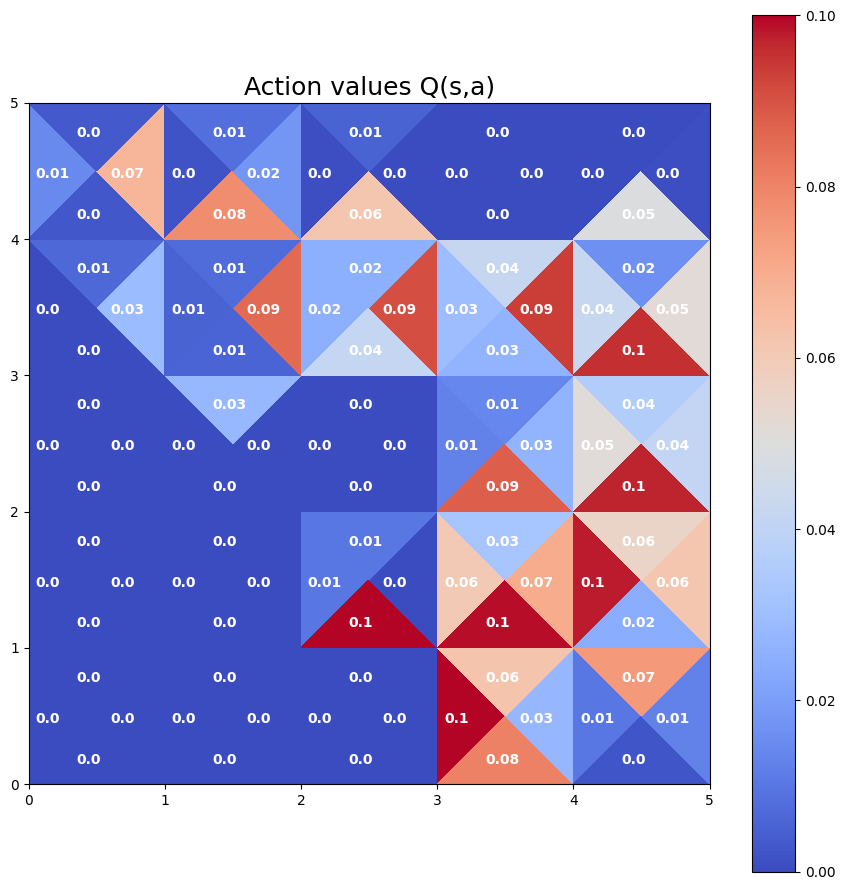

In [23]:
plot_action_values(action_values)

In [24]:
print(action_values)

[[[3.19987666e-03 6.74179872e-02 2.72044194e-03 1.46107784e-02]
  [8.05852627e-03 1.79085223e-02 7.80922577e-02 1.62920502e-03]
  [5.35288638e-03 0.00000000e+00 6.19834558e-02 6.56855716e-04]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 3.93417399e-04 4.95191067e-02 0.00000000e+00]]

 [[6.47430899e-03 2.92553610e-02 0.00000000e+00 2.88167021e-08]
  [7.19063643e-03 8.57036331e-02 5.76855787e-03 5.10715745e-03]
  [2.47189470e-02 9.08613282e-02 4.16842812e-02 2.47512881e-02]
  [4.18826398e-02 9.37332692e-02 2.64026363e-02 2.93593557e-02]
  [1.62902365e-02 5.18632432e-02 9.54920570e-02 4.24715587e-02]]

 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [2.79318059e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
  [1.40089383e-02 2.63942738e-02 8.76793531e-02 1.25805094e-02]
  [3.60254165e-02 4.10680568e-02 9.68967467e-02 5.15395164e-02]]

 [[0.00000000e+00 0.00000000e+00 0

#### Show resulting policy $\pi(\cdot|s)$

<Figure size 600x600 with 0 Axes>

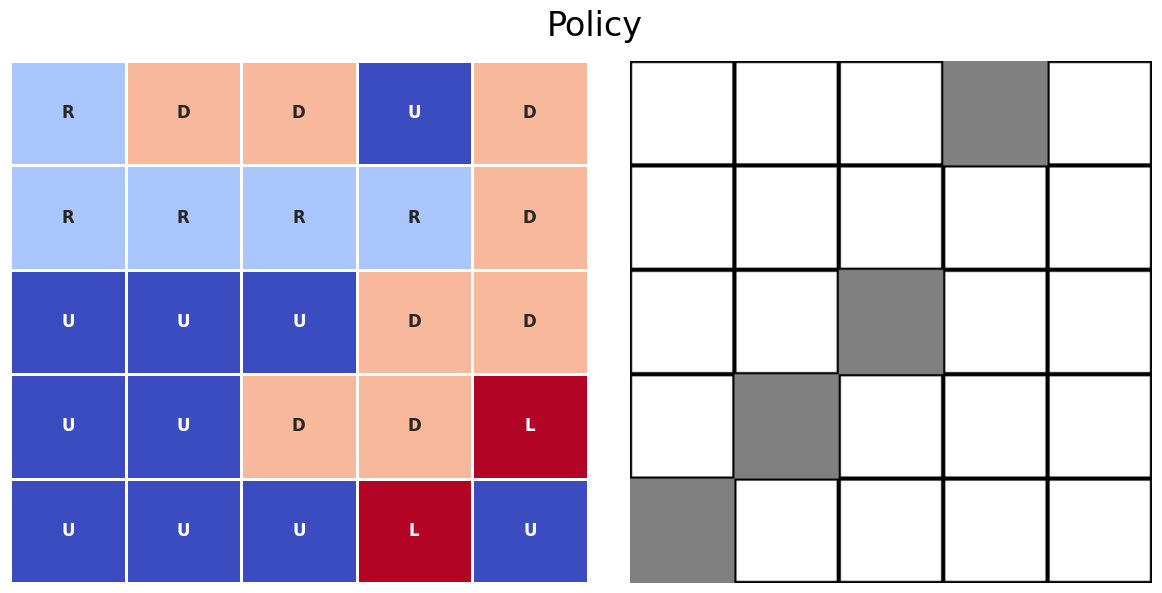

In [25]:
frame = env.render()
plt.figure(figsize=(6,6))
plot_policy(action_values, frame)

#### Test the resulting agent

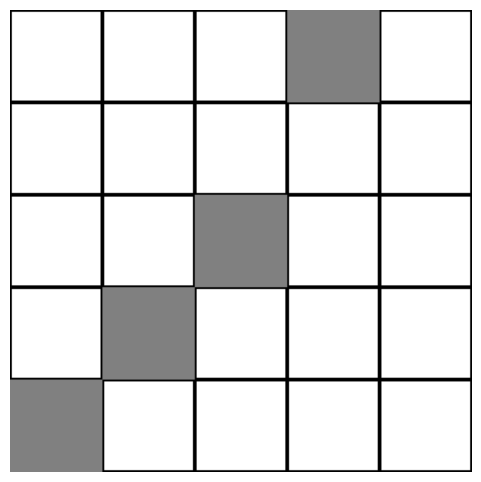

In [26]:
test_agent(env, target_policy, 1)
# test_agent(env, target_policy)